# **Field block figures**

Two standalone figures for the three tracked field blocks (Feldblöcke):

1. a 1x3 panel, one Landsat true-color close-up per block;
2. a single overview map showing all three blocks within the county.

Both are written to `outputs/` as PNGs.

In [1]:
import sys
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import rioxarray

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

from src.blocks import load_blocks
from src.config import Config

config = Config(data_dir=PROJECT_ROOT / "data", out_dir=PROJECT_ROOT / "outputs")
blocks = load_blocks().to_crs(config.epsg)

SCENE_ID = "2025-07-02_LC09_L2SP_193023_20250702_02_T1"
sr = rioxarray.open_rasterio(config.landsat_dir / f"{SCENE_ID}_sr.tif")
blocks

,FB_ID,geometry
0,DEBBLI0264002685,"POLYGON ((441881.72 5823159.62, 441907.86 5823..."
1,DEBBLI2064399462,"POLYGON ((444695.527 5834581.492, 444697.76 58..."
2,DEBBLI0264000093,"POLYGON ((443556.41 5832787.27, 443645.063 583..."


## Figure 1 — 1x3 panel, one block per axis

Landsat 9 true color (bands 1-3 = red, green, blue), cropped to a common square window around
each block, with the scene's 30 m pixel grid and the block boundary overlaid. Pixels at least
99% inside the block ("pure") are outlined in yellow; the rest of the grid is faint white.
Each band is percentile-stretched over the crop for display; raw surface reflectance is too
dark to view directly.

Wrote h:\GitHub\farmhealth\outputs\blocks_panel.png


C:\Users\das\AppData\Local\Temp\ipykernel_20776\4122851716.py:65: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


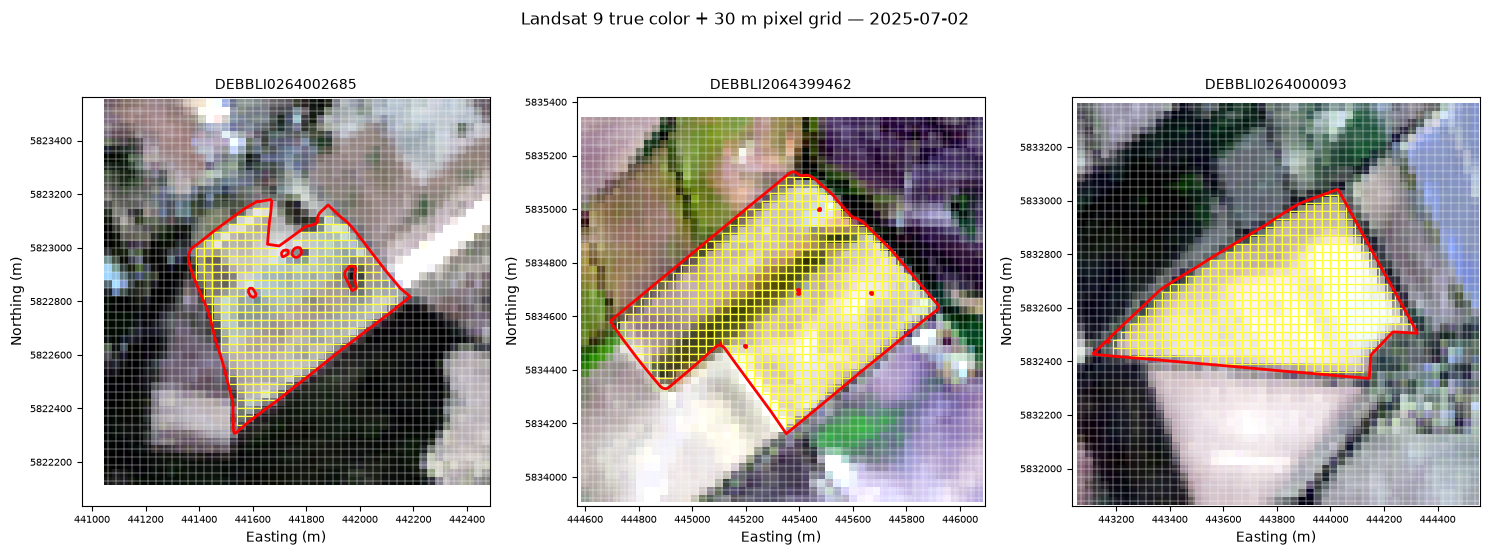

In [8]:
from src.landsat import pixel_grid

BUFFER_M = 150


def stretch(band, lo=2, hi=98):
    arr = band.values.astype("float32")
    vmin, vmax = np.nanpercentile(arr, [lo, hi])
    return np.clip((arr - vmin) / (vmax - vmin), 0, 1)


# One square window size for every block, so panels share a scale and line up;
# sized on the widest block so none is clipped.
spans = blocks.geometry.bounds
half = max((spans["maxx"] - spans["minx"]).max(), (spans["maxy"] - spans["miny"]).max()) / 2 + BUFFER_M

# The scene's own 30 m pixel grid, buffered far enough to fill each panel.
grid = pixel_grid(sr.sel(band=1), blocks, epsg=config.epsg, buffer_px=int(half // 30) + 1)


def draw_block(ax, row):
    """True color + 30 m grid + boundary for one block, on a `2 * half` m square window."""
    cx, cy = row.geometry.centroid.x, row.geometry.centroid.y
    crop = sr.sel(
        x=slice(cx - half, cx + half),
        y=slice(cy + half, cy - half),  # y descending
    )
    rgb = np.nan_to_num(np.dstack([stretch(crop.sel(band=b)) for b in (1, 2, 3)]))
    ax.imshow(
        rgb,
        extent=(float(crop.x.min()), float(crop.x.max()), float(crop.y.min()), float(crop.y.max())),
    )

    cells = grid[grid["block_id"] == row.FB_ID]
    cells.boundary.plot(ax=ax, color="white", linewidth=0.3, alpha=0.5)
    # Pure pixels (>= 99% inside the block) are the ones usable as unmixed signal.
    cells[cells["frac_in_block"] >= 0.99].plot(
        ax=ax, facecolor="none", edgecolor="yellow", linewidth=0.8
    )
    gpd.GeoSeries([row.geometry], crs=config.epsg).boundary.plot(ax=ax, color="red", linewidth=2)

    n_pure = int((cells["frac_in_block"] >= 0.99).sum())
    n_mixed = int(((cells["frac_in_block"] > 0) & (cells["frac_in_block"] < 0.99)).sum())
    ax.set_title(f"{row.FB_ID}", fontsize=10)
    ax.set_xlim(cx - half, cx + half)  # the grid extends past the window; clip back to it
    ax.set_ylim(cy - half, cy + half)
    ax.set_xlabel("Easting (m)")
    ax.set_ylabel("Northing (m)")
    ax.ticklabel_format(style="plain")
    ax.tick_params(labelsize=7)


fig, axes = plt.subplots(1, len(blocks), figsize=(5 * len(blocks), 5.5))
for ax, row in zip(np.atleast_1d(axes), blocks.itertuples()):
    draw_block(ax, row)

fig.suptitle(
    f"Landsat 9 true color + 30 m pixel grid — {SCENE_ID[:10]}\n"
    #f"{2 * half:.0f} m across each panel; yellow = pure pixels, red = block boundary"
)
fig.tight_layout()
out = config.out_dir / "blocks_panel.png"
fig.savefig(out, dpi=150)
print(f"Wrote {out}")
fig.show()

### One figure per block

The same rendering as above, but each block on its own 1x1 figure — same window size, so the
three stay comparable. Written to `outputs/blocks_panel_<FB_ID>.png`.

Wrote h:\GitHub\farmhealth\outputs\blocks_panel_DEBBLI0264002685.png


C:\Users\das\AppData\Local\Temp\ipykernel_20776\2210566930.py:9: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


Wrote h:\GitHub\farmhealth\outputs\blocks_panel_DEBBLI2064399462.png


C:\Users\das\AppData\Local\Temp\ipykernel_20776\2210566930.py:9: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


Wrote h:\GitHub\farmhealth\outputs\blocks_panel_DEBBLI0264000093.png


C:\Users\das\AppData\Local\Temp\ipykernel_20776\2210566930.py:9: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


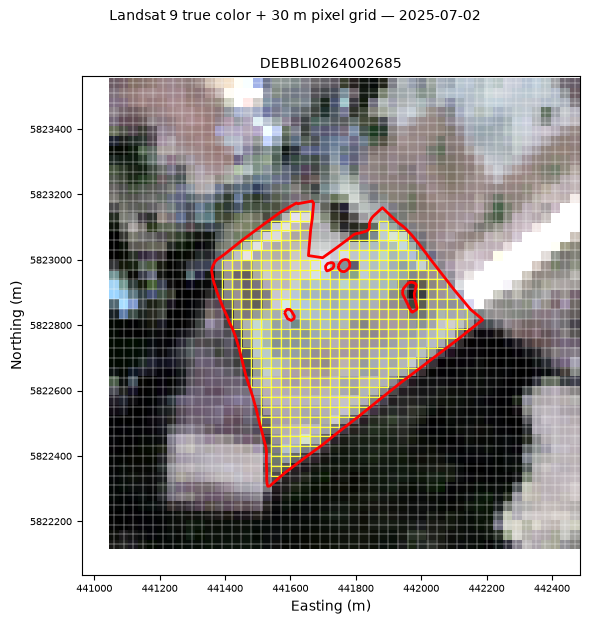

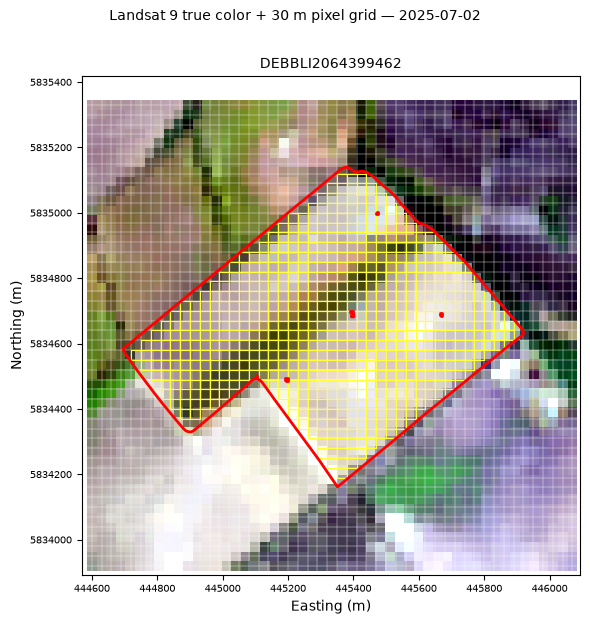

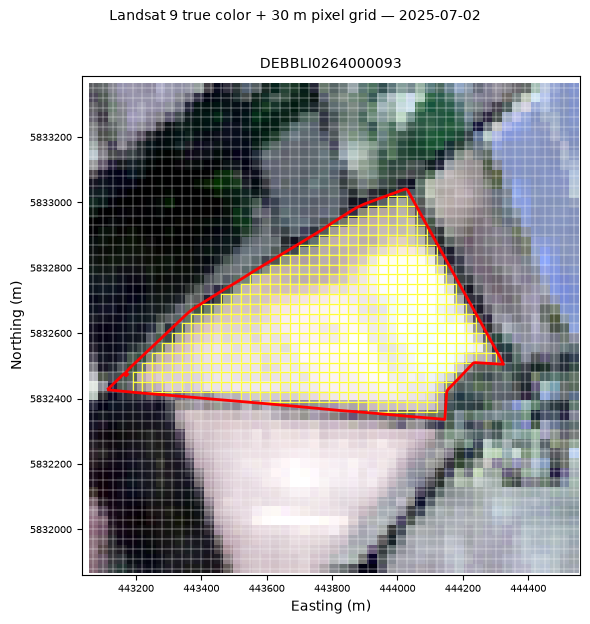

In [9]:
for row in blocks.itertuples():
    fig, ax = plt.subplots(figsize=(6, 6.5))
    draw_block(ax, row)
    fig.suptitle(f"Landsat 9 true color + 30 m pixel grid — {SCENE_ID[:10]}", fontsize=10)
    fig.tight_layout()
    out = config.out_dir / f"blocks_panel_{row.FB_ID}.png"
    fig.savefig(out, dpi=150)
    print(f"Wrote {out}")
    fig.show()

## Figure 2 — overview map of all three blocks

The three blocks in their county context, from the same VG250 Kreise layer the pipeline uses.
The inset axis zooms to the blocks' shared extent, since at county scale they are only a few
pixels across.

Wrote h:\GitHub\farmhealth\outputs\blocks_map.png


C:\Users\das\AppData\Local\Temp\ipykernel_20776\3769249807.py:58: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


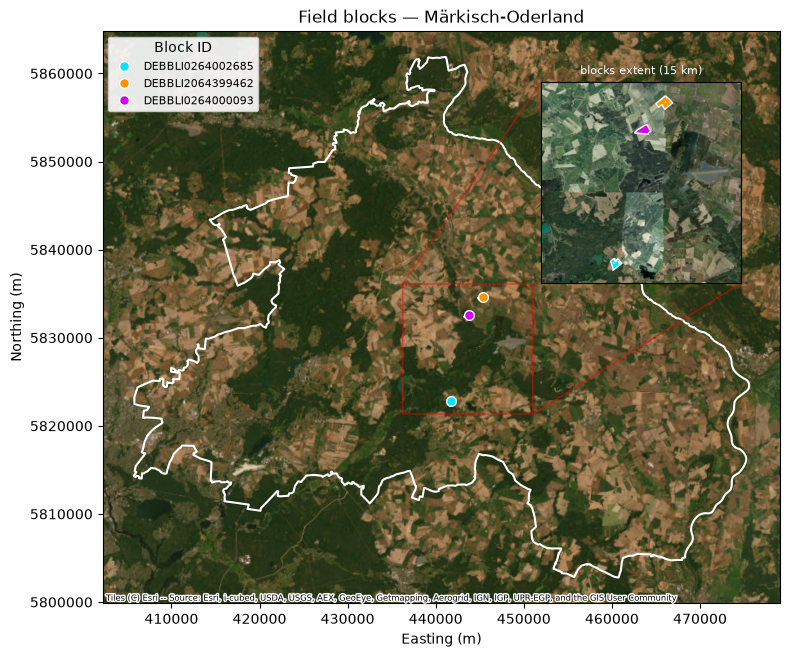

In [15]:
import contextily as cx

kreise = gpd.read_file(next(Path(config.data_dir, "vg250").rglob("*_KRS.shp")))
if "GF" in kreise.columns and (kreise["GF"] == 4).any():
    kreise = kreise[kreise["GF"] == 4]
key_col = next(c for c in ("AGS", "ARS", "RS") if c in kreise.columns)
county = kreise[kreise[key_col].astype(str).str.startswith(config.aoi_key_prefix)].to_crs(config.epsg)

COLORS = ["#00e5ff", "#ff9100", "#d500f9"]  # bright: these sit on dark satellite imagery

# Satellite basemap. Esri World Imagery is key-free; Google's XYZ endpoint needs a
# Maps Platform key (its tiles are not licensed for direct XYZ use), so to use Google
# instead, swap in:
#   BASEMAP = "https://mt1.google.com/vt/lyrs=s&x={x}&y={y}&z={z}&key=YOUR_KEY"
BASEMAP = cx.providers.Esri.WorldImagery

fig, ax = plt.subplots(figsize=(8, 8))
county.boundary.plot(ax=ax, color="white", linewidth=1.5)
for color, row in zip(COLORS, blocks.itertuples()):
    # At county scale a block is a few pixels, so mark its centroid and let the
    # legend carry the IDs — on-map labels collide at this zoom.
    gpd.GeoSeries([row.geometry], crs=config.epsg).plot(ax=ax, color=color, edgecolor="white")
    ax.plot(
        row.geometry.centroid.x, row.geometry.centroid.y,
        marker="o", markersize=7, color=color, markeredgecolor="white", linestyle="none",
        label=row.FB_ID,
    )
# Upper left: contextily prints the tile attribution along the bottom edge.
ax.legend(title="Block ID", loc="upper left", fontsize=8, framealpha=0.9)
ax.set_title(f"Field blocks — {config.aoi_name}")
ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")
ax.ticklabel_format(style="plain")

# Inset: zoom to the blocks' shared extent, forced square so the shapes aren't stretched.
minx, miny, maxx, maxy = blocks.total_bounds
cx_, cy_ = (minx + maxx) / 2, (miny + maxy) / 2
half2 = max(maxx - minx, maxy - miny) / 2 * 1.15
inset = ax.inset_axes([0.62, 0.56, 0.35, 0.35])  # y leaves room for the inset's own title
for color, row in zip(COLORS, blocks.itertuples()):
    gpd.GeoSeries([row.geometry], crs=config.epsg).plot(ax=inset, color=color, edgecolor="white")
inset.set_xlim(cx_ - half2, cx_ + half2)
inset.set_ylim(cy_ - half2, cy_ + half2)
inset.set_xticks([])
inset.set_yticks([])
inset.set_title(f"blocks extent ({2 * half2 / 1000:.0f} km)", color="white", fontsize=8)
ax.indicate_inset_zoom(inset, edgecolor="red")

# Basemap last: add_basemap reads each axis' final extent to pick the zoom level.
# Needs network on first render; tiles are then cached by contextily.
cx.add_basemap(ax, crs=config.epsg, source=BASEMAP, attribution_size=6)
cx.add_basemap(inset, crs=config.epsg, source=BASEMAP, attribution="")

fig.tight_layout()
out = config.out_dir / "blocks_map.png"
fig.savefig(out, dpi=150)
print(f"Wrote {out}")
fig.show()